# Single Type Experiment

In [1]:
import warnings;
warnings.filterwarnings('ignore');

from time import sleep
from tqdm.auto import tqdm

import sys
import importlib
import numpy as np
import nbformat
# import plotly.express
# import plotly.express as px
import pandas as pd
import scipy.optimize as optimization
import matplotlib.pyplot as plt
import seaborn as sns

### Confidence Radius

In [2]:
cup = 1
clow = 1

### Offline Optimal Solution

In [3]:
def offline_opt(budget, size, mean):
    # return [budget / np.sum(size) * size[i] for i in range(len(size))]
    return [budget / np.sum(size) for i in range(len(size))]

### Threshold Based Algorithms

In [4]:
def fixed_threshold(budget, size, mean):
    allocation = np.zeros(len(size))
    budget_remaining = budget
    
    thresh = budget / (size[0] + np.sum(mean[1:]) + clow*np.sqrt(np.log(len(size)-1) * (len(size)-1)))

    for i in range(len(allocation)):
        # allocation[i] = min(budget_remaining, thresh * size[i])
        allocation[i] = min(budget_remaining / size[i], thresh)
        budget_remaining -= allocation[i] * size[i]
    return allocation

In [5]:
def sid_threshold(budget, size, mean):
    allocation = np.zeros(len(size))
    budget_remaining = budget
    
    c = 1
    conf_bnd = (np.sum(mean[1:]))**(0.6) #c*np.sqrt(np.sum(mean)* np.log(len(size)-1)) 

    thresh_lower = budget / (size[0] + np.sum(mean[1:]) + clow*conf_bnd)
    thresh_upper = budget / (size[0] + np.sum(mean[1:]) - cup*conf_bnd)

    for i in range(len(allocation)-1):
        # TODO: add on confidence terms for (T - i) people here
        #rem = len(allocation) - (i + 1)
        budget_upper = thresh_upper*(size[i] + np.sum(mean[i+1:])) # + c*np.sqrt(rem * np.log(rem)))
        budget_lower = thresh_lower*(size[i] + np.sum(mean[i+1:])) # + c*np.sqrt(rem * np.log(rem)))

        gam = (budget_remaining - budget_lower) / (budget_upper - budget_lower)
        
        if gam >= 0.95: allocation[i] = thresh_upper
        else: allocation[i] = thresh_lower
        
        if allocation[i] * size[i] <= budget_remaining:
            budget_remaining -= allocation[i] * size[i]
        else:
            allocation[i] = budget_remaining/size[i]
            budget_remaining = 0

        if budget_remaining < 0:
            print("Error: Negative Budget")

            
    # fix for last agent
    allocation[-1] = min(thresh_upper, budget_remaining / size[-1])
    
    return allocation



In [6]:
def adapt_init_threshold(budget, size, mean):
    allocation = np.zeros(len(size))
    budget_remaining = budget
    
    

    rem = len(allocation)
    conf_bnd = np.sqrt(np.mean(mean)*(rem* np.log(rem))) 

    # calculates initial thresholds
    thresh_lower = budget / (np.sum(size[0]) + np.sum(mean[1:]) + clow*conf_bnd)
    thresh_upper = budget / (np.sum(size[0]) + np.sum(mean[1:]) - cup*conf_bnd)  
    # print(thresh_lower, thresh_upper)
    
    for i in range(len(allocation)):
    
        rem = len(allocation) - i
        conf_bnd = np.sqrt(np.mean(mean)*(rem* np.log(rem)))     
        
        
        if budget_remaining / size[i] < thresh_lower:
            # print(str(i) + ' giving rest of budget!')
            allocation[i] = budget_remaining / size[i]
        
        elif budget_remaining >= thresh_lower * (np.sum(mean[i+1:]) + clow*conf_bnd) + size[i] * thresh_upper:
            allocation[i] = thresh_upper

        else:
            allocation[i] = thresh_lower

            
        budget_remaining -= allocation[i] * size[i]

        
    if np.round(budget_remaining, 3) < 0:
        print(budget_remaining)
        print('Error: Negative Budget')
                
        
    return allocation



In [7]:
def adapt_init_under_over_threshold(budget, size, mean):
    allocation = np.zeros(len(size))
    budget_remaining = budget
    
    
    

    rem = len(allocation)
    conf_bnd = np.sqrt(np.mean(mean)*(rem* np.log(rem))) 

    # calculates initial thresholds
    thresh_lower = budget / (np.sum(size[0]) + np.sum(mean[1:]) + clow*conf_bnd)
    thresh_upper = budget / (np.sum(size[0]) + np.sum(mean[1:]) - cup*conf_bnd)  
    # print(thresh_lower, thresh_upper)
    
    
    for i in range(len(allocation)):
    
        rem = len(allocation) - i
        conf_bnd = np.sqrt(np.mean(mean)*(rem* np.log(rem)))     
        
        
        if budget_remaining / size[i] < thresh_lower:
            # print(str(i) + ' giving rest of budget!')
            allocation[i] = budget_remaining / size[i]
        
        elif budget_remaining <= thresh_upper * (np.sum(mean[i+1:]) + clow*conf_bnd) + size[i] * thresh_upper:
            allocation[i] = thresh_lower

        else:
            allocation[i] = thresh_upper

            
        budget_remaining -= allocation[i] * size[i]

        
    if np.round(budget_remaining, 3) < 0:
        print(budget_remaining)
        print('Error: Negative Budget')
                
        
    return allocation



In [8]:
def adapt_threshold(budget, size, mean):
    allocation = np.zeros(len(size))
    budget_remaining = budget
    
    
    


    rem = len(allocation)
    conf_bnd = np.sqrt(np.mean(mean)*(rem* np.log(rem))) 


    # print(thresh_lower, thresh_upper)
    
    for i in range(len(allocation)):
    
    
        rem = len(allocation) - i
        conf_bnd = np.sqrt(np.mean(mean)*(rem* np.log(rem))) 
        # calculates initial thresholds
        thresh_lower = budget / (np.sum(size[0:i+1]) + np.sum(mean[i+1:]) + clow*conf_bnd)
        thresh_upper = budget / (np.sum(size[0:i+1]) + np.sum(mean[i+1:]) - cup*conf_bnd)      
        

        
        if budget_remaining / size[i] < thresh_lower:
            # print(str(i) + ' giving rest of budget!')
            allocation[i] = budget_remaining / size[i]
        
        elif budget_remaining >= thresh_lower * (np.sum(mean[i+1:]) + clow*conf_bnd) + size[i] * thresh_upper:
            allocation[i] = thresh_upper

        else:
            allocation[i] = thresh_lower

            
        budget_remaining -= allocation[i] * size[i]

        
    if np.round(budget_remaining, 3) < 0:
        print(budget_remaining)
        print('Error: Negative Budget')
                
        
    return allocation

In [9]:
def adapt_init_threshold_new_cb(budget, size, mean):
    allocation = np.zeros(len(size))
    budget_remaining = budget
    
    
    

    rem = len(allocation)
    conf_bnd = np.sqrt(np.mean(mean)*(rem* np.log(rem))) 

    # calculates initial thresholds
    thresh_lower = budget / (np.sum(size[0]) + np.sum(mean[1:]) + clow*conf_bnd)
    thresh_upper = budget / (np.sum(size[0]) + np.sum(mean[1:]) - cup*conf_bnd)  
    # print(thresh_lower, thresh_upper)
    
    for i in range(len(allocation)):   
        
        
        if budget_remaining / size[i] < thresh_lower:
            # print(str(i) + ' giving rest of budget!')
            allocation[i] = budget_remaining / size[i]
        
        elif budget_remaining >= thresh_lower * (size[0] + np.sum(mean[1:]) + - np.sum(size[0:i+1]) + clow*conf_bnd) + size[i] * thresh_upper:
            allocation[i] = thresh_upper

        else:
            allocation[i] = thresh_lower

            
        budget_remaining -= allocation[i] * size[i]

        
    if np.round(budget_remaining, 3) < 0:
        print(budget_remaining)
        print('Error: Negative Budget')
                
        
    return allocation



### Online EG-Based Methods

In [10]:
def hope_online(budget, size, mean):
    # initialize allocation vector
    allocation = np.zeros(len(size))
    budget_remaining = budget
    for i in range(len(allocation)):
        # allocation[i] = budget_remaining * size[i] / (size[i] + np.sum(mean[i+1:]))
        allocation[i] = budget_remaining / (size[i] + np.sum(mean[i+1:]))
        
        
        budget_remaining -= allocation[i] * size[i]
    return allocation

In [11]:
def hope_full(budget, size, mean):
    allocation = np.zeros(len(size))
    budget_remaining = budget
    for i in range(len(allocation)):
#         allocation[i] = min(budget_remaining, budget*size[i] / (np.sum(size[0:i+1]) + np.sum(mean[i+1:])))
        allocation[i] = min(budget_remaining / size[i], budget / (np.sum(size[0:i+1]) + np.sum(mean[i+1:])))

        budget_remaining -= allocation[i] * size[i]
    return allocation



### Test

In [12]:
n = 6
sorted_distribution = np.asarray([np.arange(2) + 1 for x in range(n)])
weights = np.asarray([np.zeros(2)+0.5 for x in range(n)])
mean = [np.dot(weights[i], sorted_distribution[i]) for i in range(n)]

expected_demand = 1.5
budget = n * expected_demand
print(budget)

9.0


In [13]:
print(weights)

[[0.5 0.5]
 [0.5 0.5]
 [0.5 0.5]
 [0.5 0.5]
 [0.5 0.5]
 [0.5 0.5]]


In [14]:
print(sorted_distribution)

[[1 2]
 [1 2]
 [1 2]
 [1 2]
 [1 2]
 [1 2]]


In [15]:
size = [2., 1., 1., 1., 2., 1.]

In [16]:
algo_list = [offline_opt, hope_online, hope_full, adapt_init_threshold_new_cb, adapt_threshold, adapt_init_threshold, sid_threshold, fixed_threshold]

In [17]:
for algo in algo_list:
    print(algo.__name__)
    print(algo(budget, size, mean))

offline_opt
[1.125, 1.125, 1.125, 1.125, 1.125, 1.125]
hope_online
[0.94736842 1.01503759 1.10731374 1.24572796 1.06776682 1.60165023]
hope_full
[0.94736842 1.         1.05882353 1.125      1.05882353 1.125     ]
adapt_init_threshold_new_cb
[0.66589233 0.66589233 0.66589233 0.66589233 0.66589233 0.66589233]
adapt_threshold
[0.66589233 0.72148317 0.79057954 0.88032856 1.27515362 1.125     ]
adapt_init_threshold
[0.66589233 0.66589233 1.64104766 1.64104766 0.66589233 1.64104766]
sid_threshold
[0.70039249 0.70039249 0.70039249 1.46339986 0.70039249 1.46339986]
fixed_threshold
[0.72952722 0.72952722 0.72952722 0.72952722 0.72952722 0.72952722]


### Scaling with n

In [18]:
#np.random.choice(size=5, a=[1.,2.], p=[1/2, 1/2])
1+np.random.poisson(size=5,lam = 1.5)

array([1, 4, 7, 4, 1])

In [19]:
data = []

algo_list = [adapt_init_threshold_new_cb, adapt_threshold, adapt_init_threshold, sid_threshold, adapt_init_under_over_threshold, fixed_threshold]

num_iterations = 20
max_n = 100

mean_size = 1.5

for n in tqdm(np.arange(2,max_n+1)):
    expected_size = np.zeros(n) + mean_size
    budget = n
    
    for i in range(num_iterations):
        # size = np.random.choice(size=n, a=[1.,2.], p=[1/2, 1/2])
        size = 1+np.random.poisson(size=n,lam = mean_size-1)
        
        opt = offline_opt(budget, size, expected_size)
        
        for algo in algo_list:
            sol = algo(budget, size, expected_size)
            
            data_dict = {'NumGroups': n, 'Algorithm':algo.__name__, 'Norm': 'L1', 'Value': np.sum(np.abs(opt-sol))}
            data.append(data_dict)
            data_dict = {'NumGroups': n, 'Algorithm':algo.__name__, 'Norm': 'Linf', 'Value': np.max(np.abs(opt-sol))}
            data.append(data_dict)
            data_dict = {'NumGroups': n, 'Algorithm':algo.__name__, 'Norm': 'Waste', 'Value': budget - np.dot(size, sol)}
            data.append(data_dict)
        
    sleep(0)

  0%|          | 0/99 [00:00<?, ?it/s]

<AxesSubplot:title={'center':'Simple Distribution Waste'}, xlabel='NumGroups', ylabel='Value'>

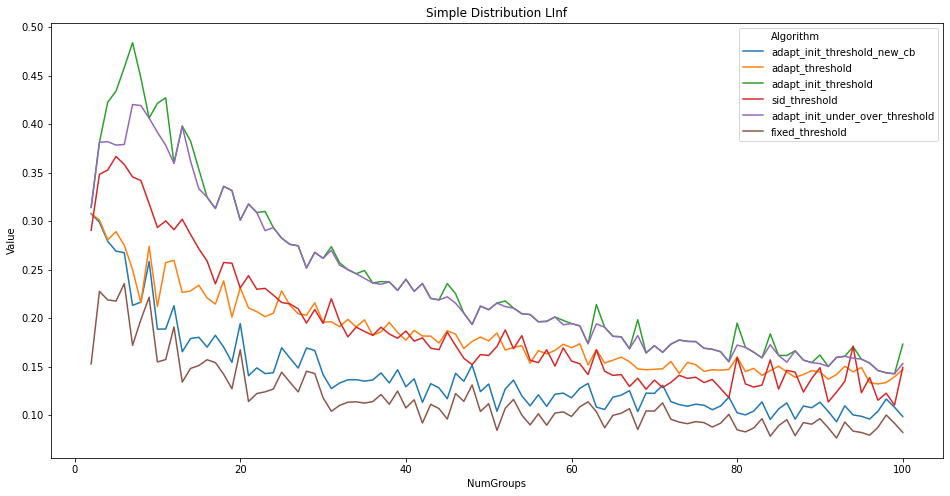

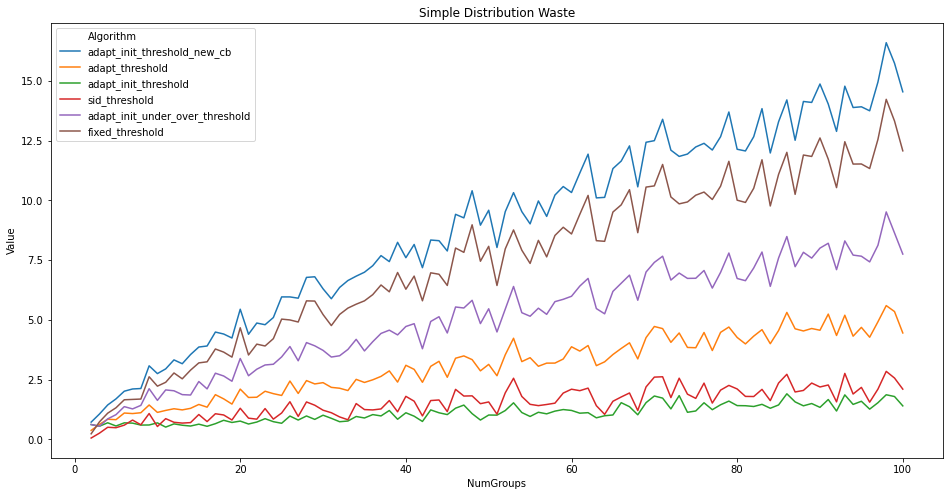

In [20]:
df = pd.DataFrame.from_records(data)
df.columns


#filled_markers = ('o', 'v', '^', '<', '>', '8', 's', 'p', '*', 'h', 'H', 'D', 'd', 'P', 'X')
#plt.figure(figsize=(20,10))
#plt.title('Simple Distribution L1')
#sns.lineplot(x='NumGroups', y='value', hue='variable', data=df[df.Norm == 'L1'])

filled_markers = ('o', 'v', '^', '<', '>', '8', 's', 'p', '*', 'h', 'H', 'D', 'd', 'P', 'X')
plt.figure(figsize=(16,8))
plt.title('Simple Distribution LInf')
sns.lineplot(x='NumGroups', y='Value', hue='Algorithm', data=df[df.Norm == 'Linf'], ci=None)


filled_markers = ('o', 'v', '^', '<', '>', '8', 's', 'p', '*', 'h', 'H', 'D', 'd', 'P', 'X')
plt.figure(figsize=(16,8))
plt.title('Simple Distribution Waste')
sns.lineplot(x='NumGroups', y='Value', hue='Algorithm', data=df[df.Norm == 'Waste'], ci=None)


### Group by Group Difference

In [21]:
data = []

n = 100
num_iterations = 100

mean_size = 1.5
expected_size = np.zeros(n) + mean_size

for i in tqdm(range(num_iterations)):
    
    expected_size = np.zeros(n) + mean_size
    budget = n
    size = np.random.choice(size=n, a=[1.,2.], p=[1/2, 1/2])
    
    opt = offline_opt(budget, size, expected_size)
    for algo in algo_list:
        sol = algo(budget, size, expected_size)
        for i in range(n):
            data.append({'Location':i, 'Algorithm':algo.__name__, 'Value': opt[i] - sol[i]})
            
    for i in range(n):
        data.append({'Location': i, 'Algorithm':'Zero', 'Value': 0})

  0%|          | 0/100 [00:00<?, ?it/s]

[]

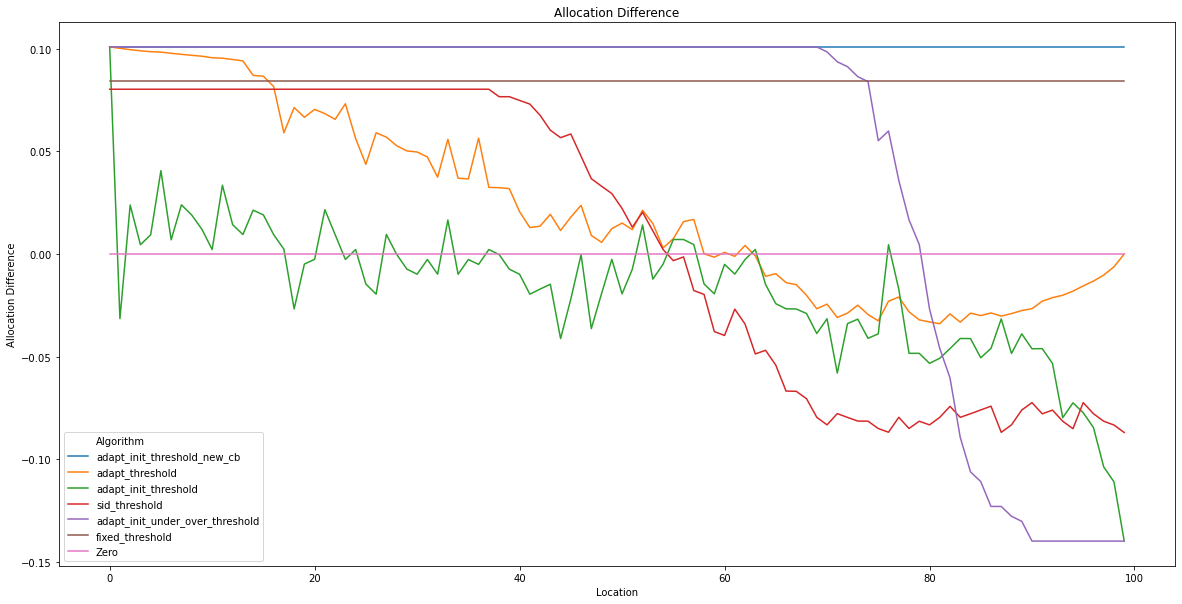

In [22]:
df = pd.DataFrame.from_records(data)

plt.figure(figsize=(20,10))
sns.lineplot(x='Location', y='Value', hue = 'Algorithm', data=df, ci = None)
plt.title('Allocation Difference')
plt.xlabel('Location')
plt.ylabel('Allocation Difference')
plt.plot()

Note: Discrepancy is between where max and average are between this plot and the other one.